# CNN-B — El Robusto: EMNIST Digits + augmentación agresiva

**Dataset:** EMNIST Digits — 280.000 imágenes con mucha más variedad de estilos de escritura  
**Arquitectura:** 3 bloques Conv→BatchNorm→MaxPool + GlobalAvgPool + capas densas  
**Augmentación:** rotación, traslación, zoom, ruido — simula escritura imperfecta con el ratón  
**Objetivo:** modelo robusto que reconozca bien dígitos dibujados a mano en la app interactiva

> **¿Por qué EMNIST?**  
> MNIST tiene imágenes limpias y centradas. EMNIST Digits tiene 280k imágenes con mayor
> variedad de grosor de trazo, inclinación y estilo. Más diversidad en training = mejor
> generalización cuando dibujas con el ratón.

---
## Índice
1. Imports y configuración
2. Carga de EMNIST desde el zip local (Kaggle)
3. Exploración y visualización
4. División train/val
5. Data Augmentation
6. Arquitectura del modelo
7. Entrenamiento
8. Evaluación y análisis de errores
9. Comparativa CNN-A vs CNN-B
10. Guardado del modelo

---
## 1. Imports y configuración

In [1]:
import os
import zipfile
import struct
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'font.size': 11})

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow: 2.15.0
GPU disponible: False


---
## 2. Carga de EMNIST desde el zip local

Leemos los ficheros IDX binarios directamente desde el zip de Kaggle — sin descomprimir nada.
El formato IDX es idéntico al de MNIST: cabecera de 16 bytes + píxeles en bruto.

**Ajusta `ZIP_PATH`** si el zip no está en tu carpeta de Descargas.

In [2]:
# ── Ajusta esta ruta si el zip está en otro sitio ──────────────────────────
ZIP_PATH = r'C:\Users\nunez\Downloads\archive.zip'
# ───────────────────────────────────────────────────────────────────────────

def leer_idx_images(zf, nombre):
    """Lee un fichero IDX de imágenes desde un ZipFile abierto."""
    with zf.open(nombre) as f:
        data = f.read()
    magic, n, rows, cols = struct.unpack('>4I', data[:16])
    assert magic == 2051, f'Magic incorrecto: {magic}'
    return np.frombuffer(data[16:], dtype=np.uint8).reshape(n, rows, cols)

def leer_idx_labels(zf, nombre):
    """Lee un fichero IDX de etiquetas desde un ZipFile abierto."""
    with zf.open(nombre) as f:
        data = f.read()
    magic, n = struct.unpack('>2I', data[:8])
    assert magic == 2049, f'Magic incorrecto: {magic}'
    return np.frombuffer(data[8:], dtype=np.uint8)

print('Cargando EMNIST Digits desde zip local...')
with zipfile.ZipFile(ZIP_PATH) as zf:
    X_train_raw  = leer_idx_images(zf, 'emnist_source_files/emnist-digits-train-images-idx3-ubyte')
    y_train_full = leer_idx_labels(zf, 'emnist_source_files/emnist-digits-train-labels-idx1-ubyte')
    X_test_raw   = leer_idx_images(zf, 'emnist_source_files/emnist-digits-test-images-idx3-ubyte')
    y_test       = leer_idx_labels(zf, 'emnist_source_files/emnist-digits-test-labels-idx1-ubyte')

print(f'Train raw: {X_train_raw.shape}  dtype={X_train_raw.dtype}')
print(f'Test raw:  {X_test_raw.shape}')
print(f'Clases: {np.unique(y_train_full)}')
print(f'Total: {len(X_train_raw)+len(X_test_raw):,} muestras  (MNIST tenía 70.000)')

Cargando EMNIST Digits desde zip local...
Train raw: (240000, 28, 28)  dtype=uint8
Test raw:  (40000, 28, 28)
Clases: [0 1 2 3 4 5 6 7 8 9]
Total: 280,000 muestras  (MNIST tenía 70.000)


In [3]:
def preparar_emnist(X_raw):
    """Corrige orientación, normaliza y añade canal."""
    X = np.transpose(X_raw, (0, 2, 1))   # EMNIST viene transpuesto
    X = np.flip(X, axis=2)               # voltear horizontal
    X = X.astype('float32') / 255.0
    X = X[..., np.newaxis]               # (N, 28, 28, 1)
    return X

X_train_full = preparar_emnist(X_train_raw)
X_test       = preparar_emnist(X_test_raw)

print(f'X_train_full: {X_train_full.shape}')
print(f'X_test:       {X_test.shape}')
print(f'Rango: [{X_train_full.min():.1f}, {X_train_full.max():.1f}]')

X_train_full: (240000, 28, 28, 1)
X_test:       (40000, 28, 28, 1)
Rango: [0.0, 1.0]


---
## 3. Exploración y visualización

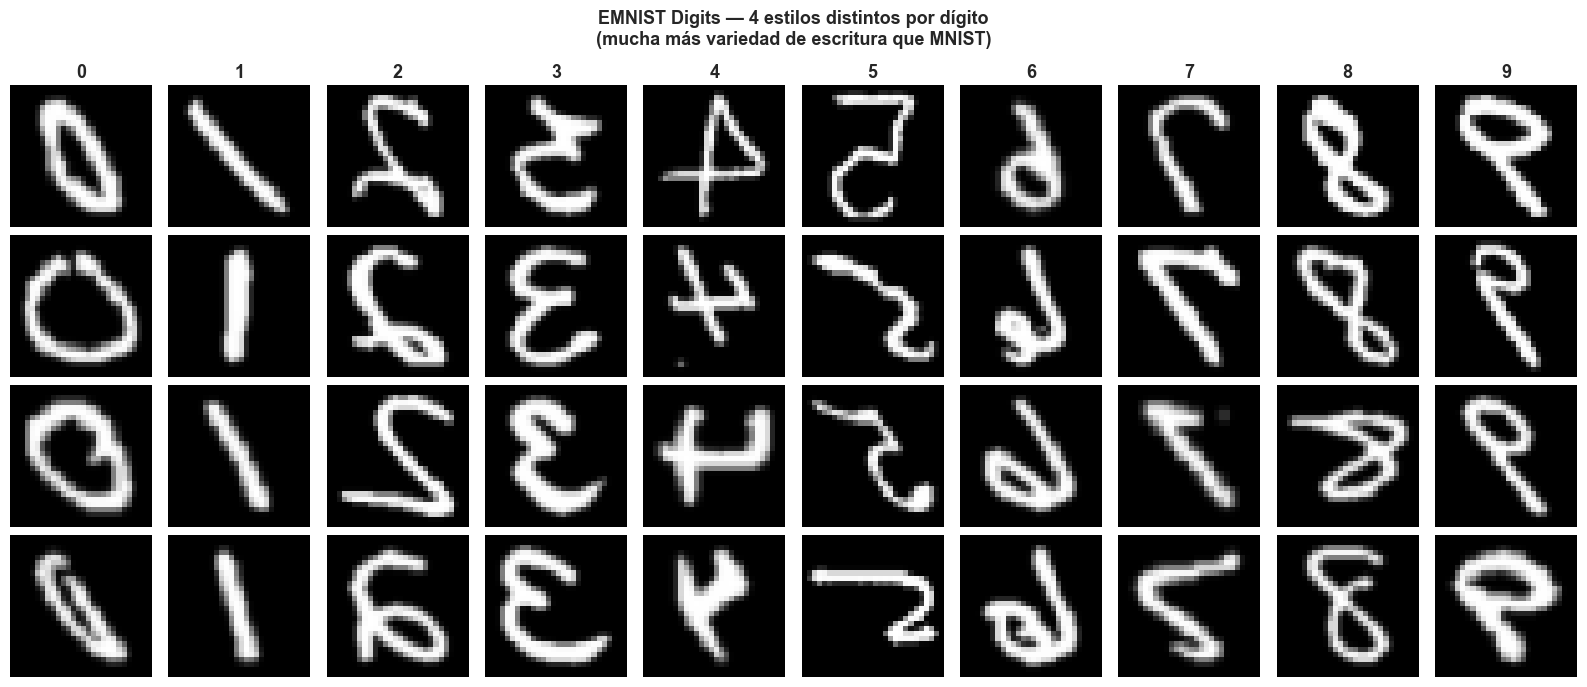

In [4]:
fig, axes = plt.subplots(4, 10, figsize=(16, 7))

for digit in range(10):
    idxs = np.where(y_train_full == digit)[0]
    for row, sample_idx in enumerate([0, 5, 20, 80]):
        axes[row, digit].imshow(X_train_full[idxs[sample_idx]].squeeze(), cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=13, fontweight='bold')

plt.suptitle('EMNIST Digits — 4 estilos distintos por dígito\n(mucha más variedad de escritura que MNIST)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

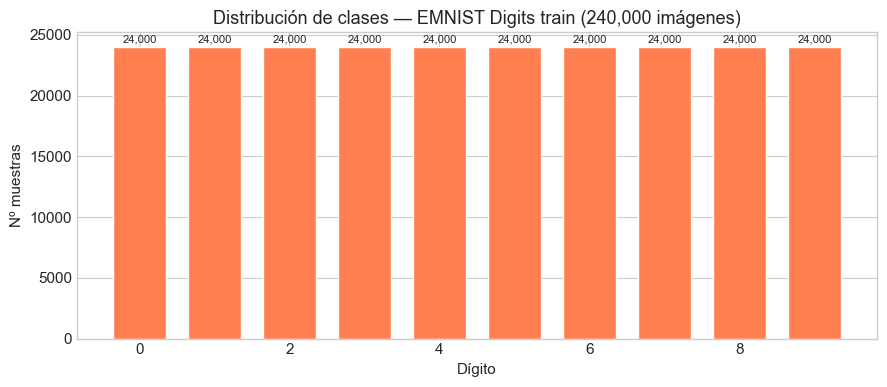

Mínimo: 24,000 | Máximo: 24,000
Ratio max/min: 1.00x — dataset equilibrado


In [5]:
unique, counts = np.unique(y_train_full, return_counts=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(unique, counts, color='coral', edgecolor='white', width=0.7)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{c:,}', ha='center', va='bottom', fontsize=8)
ax.set_title(f'Distribución de clases — EMNIST Digits train ({len(y_train_full):,} imágenes)', fontsize=13)
ax.set_xlabel('Dígito')
ax.set_ylabel('Nº muestras')
plt.tight_layout()
plt.show()

print(f'Mínimo: {counts.min():,} | Máximo: {counts.max():,}')
print(f'Ratio max/min: {counts.max()/counts.min():.2f}x — dataset equilibrado')

---
## 4. División train/val

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full
)

print(f'Train: {X_train.shape}   ({len(X_train):,} imgs)')
print(f'Val:   {X_val.shape}   ({len(X_val):,} imgs)')
print(f'Test:  {X_test.shape}   ({len(X_test):,} imgs)')

Train: (204000, 28, 28, 1)   (204,000 imgs)
Val:   (36000, 28, 28, 1)   (36,000 imgs)
Test:  (40000, 28, 28, 1)   (40,000 imgs)


---
## 5. Data Augmentation

Las capas de augmentación van **dentro del modelo** y solo se activan durante training.  
En la app (inferencia), no aplican ninguna transformación.

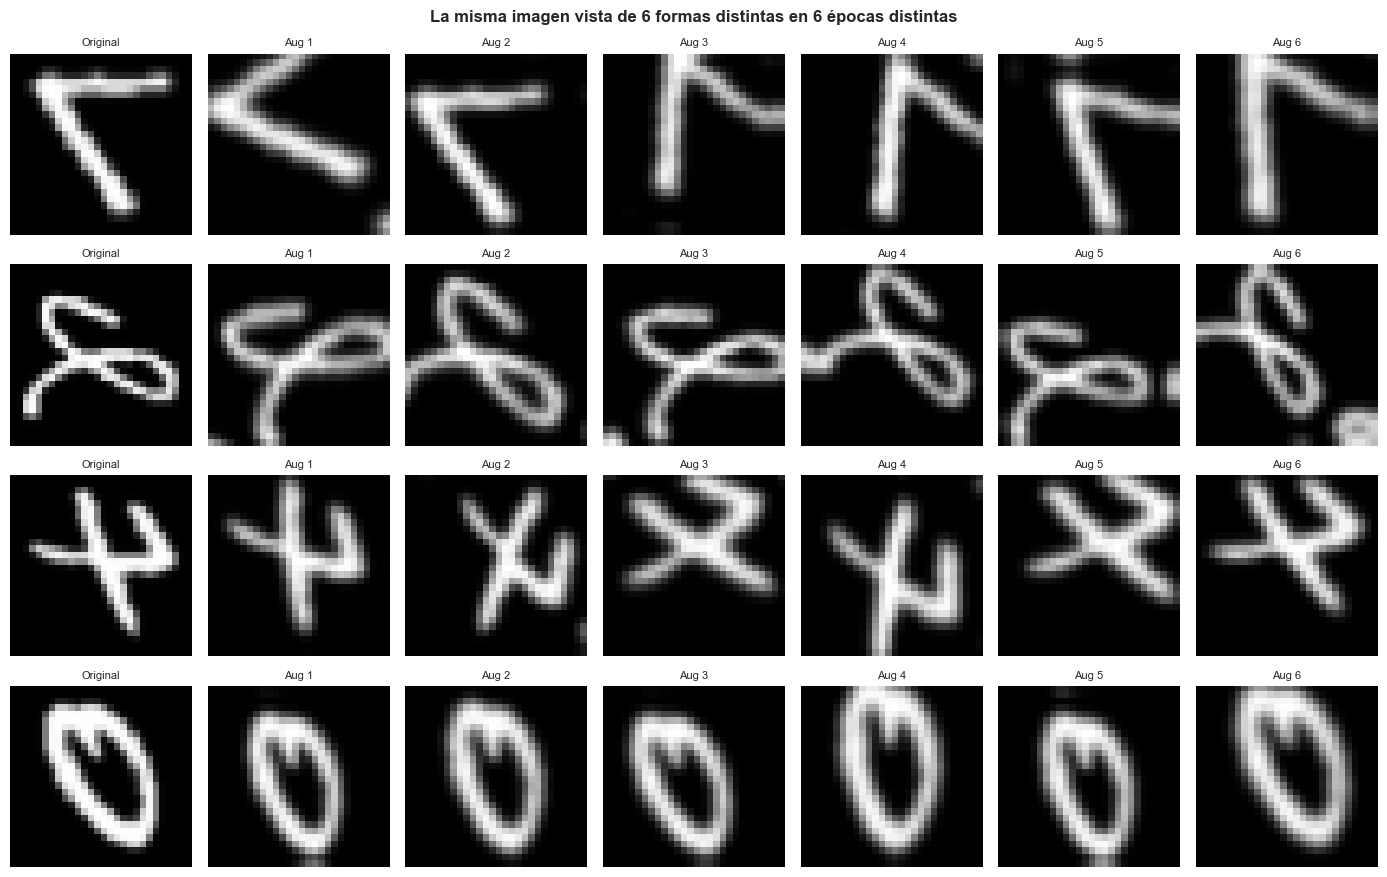

In [7]:
augmentation = keras.Sequential([
    layers.RandomRotation(0.12),          # ±43°
    layers.RandomTranslation(0.1, 0.1),   # ±10%
    layers.RandomZoom(0.1),               # ±10%
], name='augmentation')

# Visualizar el efecto
sample = X_train[:4]
fig, axes = plt.subplots(4, 7, figsize=(14, 9))
for i in range(4):
    axes[i, 0].imshow(sample[i].squeeze(), cmap='gray')
    axes[i, 0].set_title('Original', fontsize=8)
    axes[i, 0].axis('off')
    for j in range(1, 7):
        aug_img = augmentation(sample[i:i+1], training=True)[0]
        axes[i, j].imshow(aug_img.numpy().squeeze(), cmap='gray')
        axes[i, j].set_title(f'Aug {j}', fontsize=8)
        axes[i, j].axis('off')

plt.suptitle('La misma imagen vista de 6 formas distintas en 6 épocas distintas',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Arquitectura del modelo — CNN-B

```
Input (28×28×1)
  → [Augmentation — solo en training]
  → Conv2D(32) → BatchNorm → ReLU → MaxPool   ← 14×14
  → Conv2D(64) → BatchNorm → ReLU → MaxPool   ← 7×7
  → Conv2D(128) → BatchNorm → ReLU            ← 7×7
  → GlobalAveragePooling2D                    ← 128 valores
  → Dense(256, relu) → Dropout(0.5)
  → Dense(10, softmax)
```

**BatchNorm:** normaliza activaciones entre capas — entrenamiento más estable.  
**GlobalAvgPool:** media de cada mapa de características → muchos menos parámetros que Flatten.

In [8]:
def build_cnn_b():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        augmentation,

        # Bloque 1
        layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Bloque 2
        layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Bloque 3 — extra vs CNN-A
        layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='CNN_B_EMNIST_Robusto')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_b = build_cnn_b()
model_b.summary()


Model: "CNN_B_EMNIST_Robusto"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 augmentation (Sequential)   (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        288       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 32)        128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 6

---
## 7. Entrenamiento

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

history_b = model_b.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/35


1594/1594 [==============================] - 130s 80ms/step - loss: 0.2441 - accuracy: 0.9272 - val_loss: 0.3473 - val_accuracy: 0.8908 - lr: 0.0010
Epoch 2/35
1594/1594 [==============================] - 127s 80ms/step - loss: 0.0835 - accuracy: 0.9755 - val_loss: 0.1866 - val_accuracy: 0.9449 - lr: 0.0010
Epoch 3/35
1594/1594 [==============================] - 130s 81ms/step - loss: 0.0681 - accuracy: 0.9805 - val_loss: 0.2329 - val_accuracy: 0.9184 - lr: 0.0010
Epoch 4/35
1594/1594 [==============================] - 138s 87ms/step - loss: 0.0588 - accuracy: 0.9828 - val_loss: 0.0733 - val_accuracy: 0.9772 - lr: 0.0010
Epoch 5/35
1594/1594 [==============================] - 138s 86ms/step - loss: 0.0531 - accuracy: 0.9845 - val_loss: 0.0355 - val_accuracy: 0.9891 - lr: 0.0010
Epoch 6/35
1594/1594 [==============================] - 158s 99ms/step - loss: 0.0481 - accuracy: 0.9861 - val_loss: 0.0693 - val_accuracy: 0.9787 - lr: 0.0010
Epoch 7/35
1594/1594 [================

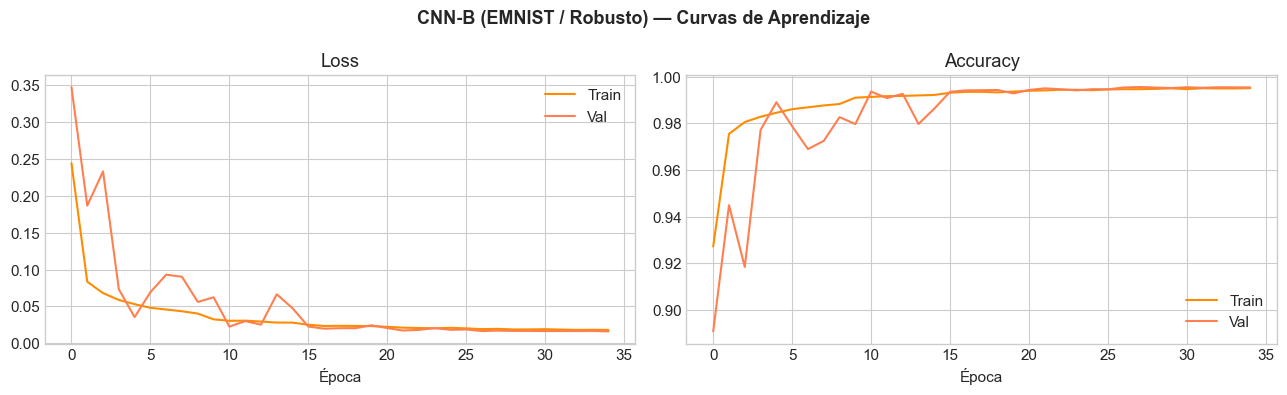

Entrenamiento: 35 épocas


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_b.history['loss'],     label='Train', color='darkorange')
axes[0].plot(history_b.history['val_loss'], label='Val',   color='coral')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_b.history['accuracy'],     label='Train', color='darkorange')
axes[1].plot(history_b.history['val_accuracy'], label='Val',   color='coral')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.suptitle('CNN-B (EMNIST / Robusto) — Curvas de Aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Entrenamiento: {len(history_b.history["loss"])} épocas')

---
## 8. Evaluación y análisis de errores

In [11]:
test_loss, test_acc = model_b.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')

y_pred = np.argmax(model_b.predict(X_test, verbose=0), axis=1)
print()
print(classification_report(y_test, y_pred, digits=4))

Test Loss:     0.0173
Test Accuracy: 99.51%

              precision    recall  f1-score   support

           0     0.9968    0.9970    0.9969      4000
           1     0.9985    0.9925    0.9955      4000
           2     0.9970    0.9938    0.9954      4000
           3     0.9952    0.9950    0.9951      4000
           4     0.9930    0.9958    0.9944      4000
           5     0.9940    0.9965    0.9953      4000
           6     0.9960    0.9945    0.9952      4000
           7     0.9950    0.9968    0.9959      4000
           8     0.9886    0.9958    0.9922      4000
           9     0.9970    0.9935    0.9952      4000

    accuracy                         0.9951     40000
   macro avg     0.9951    0.9951    0.9951     40000
weighted avg     0.9951    0.9951    0.9951     40000



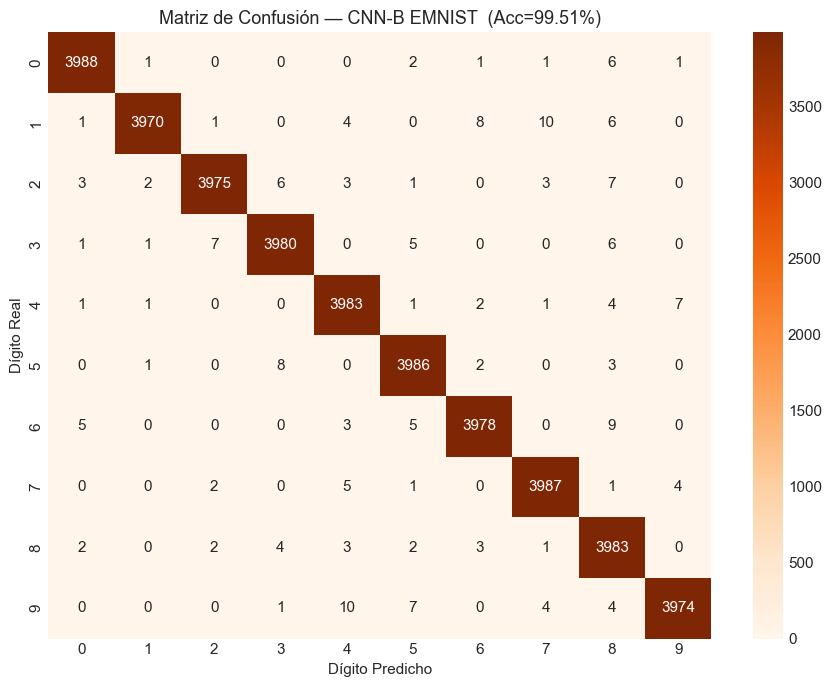

Par más confundido: real=1 predicho como 7 (10 veces)


In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Dígito Predicho')
ax.set_ylabel('Dígito Real')
ax.set_title(f'Matriz de Confusión — CNN-B EMNIST  (Acc={test_acc*100:.2f}%)', fontsize=13)
plt.tight_layout()
plt.show()

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
max_err = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
print(f'Par más confundido: real={max_err[0]} predicho como {max_err[1]} ({cm_no_diag[max_err]} veces)')

Errores: 196 de 40000 (0.49%)


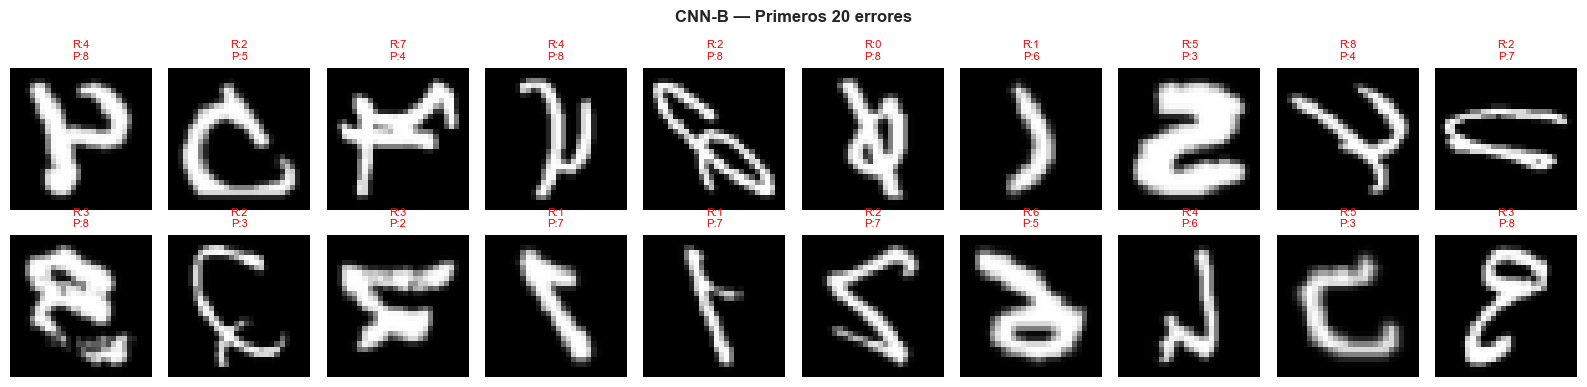

In [13]:
wrong_idx = np.where(y_pred != y_test)[0]
print(f'Errores: {len(wrong_idx)} de {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.2f}%)')

n_show = min(20, len(wrong_idx))
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i, idx in enumerate(wrong_idx[:n_show]):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    ax.set_title(f'R:{y_test[idx]}\nP:{y_pred[idx]}', fontsize=8, color='red')
    ax.axis('off')

plt.suptitle('CNN-B — Primeros 20 errores', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Comparativa CNN-A vs CNN-B

=== COMPARATIVA FINAL (test EMNIST) ===
  CNN-A (LeNet/MNIST)     36.19%  <- entrenado en MNIST, evaluado en EMNIST
  CNN-B (Robusto/EMNIST)  99.51%  <- entrenado y evaluado en EMNIST


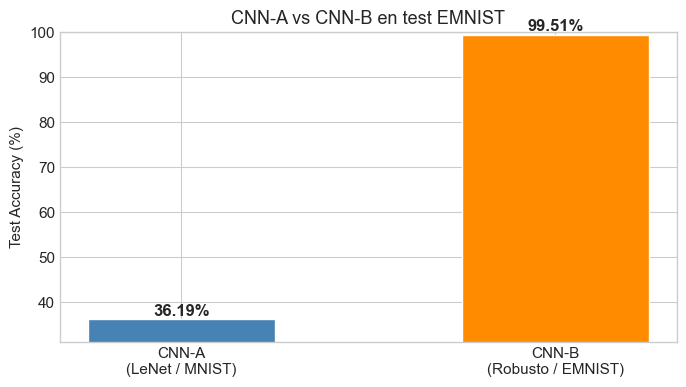

In [14]:
cnn_a_path = '../models/cnn_a_mnist.keras'

if os.path.exists(cnn_a_path):
    cnn_a = keras.models.load_model(cnn_a_path)
    _, acc_a = cnn_a.evaluate(X_test, y_test, verbose=0)

    print('=== COMPARATIVA FINAL (test EMNIST) ===')
    print(f'  CNN-A (LeNet/MNIST)     {acc_a*100:.2f}%  <- entrenado en MNIST, evaluado en EMNIST')
    print(f'  CNN-B (Robusto/EMNIST)  {test_acc*100:.2f}%  <- entrenado y evaluado en EMNIST')

    fig, ax = plt.subplots(figsize=(7, 4))
    modelos = ['CNN-A\n(LeNet / MNIST)', 'CNN-B\n(Robusto / EMNIST)']
    accs = [acc_a * 100, test_acc * 100]
    colors = ['steelblue', 'darkorange']
    bars = ax.bar(modelos, accs, color=colors, edgecolor='white', width=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylim(min(accs) - 5, 100)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('CNN-A vs CNN-B en test EMNIST', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('CNN-A no encontrada. Ejecuta cnn_a_mnist.ipynb primero.')
    print(f'CNN-B Test Accuracy: {test_acc*100:.2f}%')

---
## 10. Guardado del modelo

In [15]:
os.makedirs('../models', exist_ok=True)
model_b.save('../models/cnn_b_emnist.keras')
print('Guardado: ../models/cnn_b_emnist.keras')

loaded = keras.models.load_model('../models/cnn_b_emnist.keras')
_, acc_loaded = loaded.evaluate(X_test[:1000], y_test[:1000], verbose=0)
print(f'Verificación tras carga: accuracy = {acc_loaded*100:.2f}%')
print()
print('=== RESUMEN CNN-B ===')
print(f'  Dataset:       EMNIST Digits ({len(X_train_full):,} train + {len(X_test):,} test)')
print(f'  Arquitectura:  3x(Conv->BN->ReLU->Pool) -> GlobalAvgPool -> Dense256 -> Dense10')
print(f'  Augmentacion:  Rotacion, Traslacion, Zoom')
print(f'  Test Accuracy: {test_acc*100:.2f}%')
print()
print('Siguiente: streamlit run ../app/app.py')

Guardado: ../models/cnn_b_emnist.keras
Verificación tras carga: accuracy = 99.70%

=== RESUMEN CNN-B ===
  Dataset:       EMNIST Digits (240,000 train + 40,000 test)
  Arquitectura:  3x(Conv->BN->ReLU->Pool) -> GlobalAvgPool -> Dense256 -> Dense10
  Augmentacion:  Rotacion, Traslacion, Zoom
  Test Accuracy: 99.51%

Siguiente: streamlit run ../app/app.py
